In [1]:
print("hello deep CNN")

hello deep CNN


In [2]:
!pip install kaggle==1.5.16

In [3]:
! chmod 600 .kaggle/kaggle.json

chmod: cannot access '.kaggle/kaggle.json': No such file or directory


In [4]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
replace example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: example_submission.csv  
replace fer2013.tar.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fer2013.tar.gz          
replace icml_face_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: icml_face_data.csv      
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: test.csv                
  inflating: train.csv               A



In [6]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam, SGD, RMSpropy # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [7]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

In [8]:
x_train = np.array([
    list(map(int, row.split()))
    for row in train_df['pixels']
]).reshape(-1, 48, 48)

y_train = train_df['emotion'].values

In [9]:
from sklearn.model_selection import train_test_split

x_train = x_train / 255.0
x_train = x_train.reshape(-1, 1, 48, 48)

X_train, X_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (22967, 1, 48, 48)
Val shape: (5742, 1, 48, 48)


In [10]:
class FERDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset = FERDataset(X_train, y_train)
val_dataset   = FERDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [11]:
class DeepCNN(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super(DeepCNN, self).__init__()

        # Block 1: 1 → 64 | output: (64, 24, 24)
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)
        )

        # Block 2: 64 → 128 | output: (128, 12, 12)
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)
        )

        # Block 3: 128 → 256 | output: (256, 6, 6)
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)
        )

        # Block 4: 256 → 512 | output: (512, 3, 3)
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)
        )

        # Classifier
        self.fc = nn.Sequential(
            nn.Flatten(),                       # 512*3*3 = 4608
            nn.Linear(512 * 3 * 3, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.fc(x)
        return x

# Sanity check
model = DeepCNN().to(device)
print(model)

dummy = torch.randn(1, 1, 48, 48).to(device)
print("Output shape:", model(dummy).shape)  # should be torch.Size([1, 7])

DeepCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fa

In [12]:
from torchvision import transforms
from torch.utils.data import Dataset

class FERDatasetAugmented(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.1, 0.1)   # slight shift
            ),
        ]) if augment else None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        if self.augment and self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Augmented dataset only for training, not validation
train_dataset_aug = FERDatasetAugmented(X_train, y_train, augment=True)
val_dataset_aug   = FERDatasetAugmented(X_val, y_val, augment=False)

In [13]:
!pip install wandb -q
import wandb
wandb.login()  # will prompt for API key

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ikvas22 (ikvas22-free-university-of-tbilisi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

[deep-cnn-adam-lr0.001-drop0.25] Epoch 1/50 | Train Loss: 1.8339 Acc: 0.2353 | Val Loss: 1.8006 Acc: 0.2551 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.25] Epoch 2/50 | Train Loss: 1.8064 Acc: 0.2516 | Val Loss: 1.8042 Acc: 0.2572 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.25] Epoch 3/50 | Train Loss: 1.7932 Acc: 0.2568 | Val Loss: 1.8180 Acc: 0.2005 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.25] Epoch 4/50 | Train Loss: 1.7458 Acc: 0.2867 | Val Loss: 1.6738 Acc: 0.3232 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.25] Epoch 5/50 | Train Loss: 1.6684 Acc: 0.3290 | Val Loss: 1.5252 Acc: 0.3981 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.25] Epoch 6/50 | Train Loss: 1.5768 Acc: 0.3750 | Val Loss: 1.4599 Acc: 0.4228 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.25] Epoch 7/50 | Train Loss: 1.5170 Acc: 0.3915 | Val Loss: 1.4458 Acc: 0.4286 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.25] Epoch 8/50 | Train Loss: 1.4722 Acc: 0.4146 | Val Loss: 1.3836 Acc: 0.4356 | LR: 0.001000
[deep-cnn-adam-l

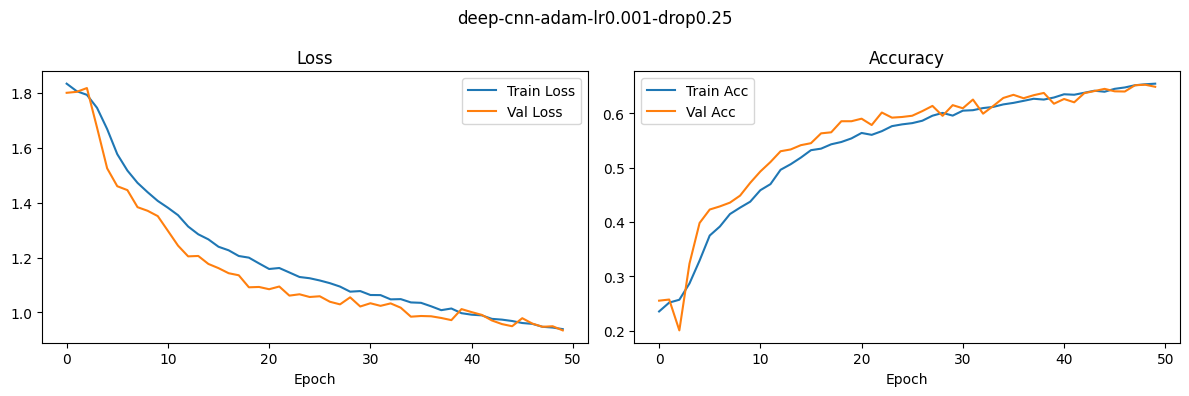

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▁▂▃▄▄▄▄▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,███▇▇▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/accuracy,▂▂▁▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████▇████████
val/loss,███▇▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▂▁▁▁▁▁▁▁
best_val_accuracy,0.65256
best_val_loss,0.93422
epoch,50
final_train_accuracy,0.65446
learning_rate,0.001



✅ Finished: deep-cnn-adam-lr0.001-drop0.25



[deep-cnn-adam-lr0.0001-drop0.25] Epoch 1/50 | Train Loss: 1.8269 Acc: 0.2250 | Val Loss: 1.7692 Acc: 0.2584 | LR: 0.000100
[deep-cnn-adam-lr0.0001-drop0.25] Epoch 2/50 | Train Loss: 1.7503 Acc: 0.2812 | Val Loss: 1.5412 Acc: 0.4082 | LR: 0.000100
[deep-cnn-adam-lr0.0001-drop0.25] Epoch 3/50 | Train Loss: 1.5540 Acc: 0.3930 | Val Loss: 1.4568 Acc: 0.4411 | LR: 0.000100
[deep-cnn-adam-lr0.0001-drop0.25] Epoch 4/50 | Train Loss: 1.4531 Acc: 0.4334 | Val Loss: 1.3108 Acc: 0.4977 | LR: 0.000100
[deep-cnn-adam-lr0.0001-drop0.25] Epoch 5/50 | Train Loss: 1.3875 Acc: 0.4601 | Val Loss: 1.2704 Acc: 0.5061 | LR: 0.000100
[deep-cnn-adam-lr0.0001-drop0.25] Epoch 6/50 | Train Loss: 1.3385 Acc: 0.4820 | Val Loss: 1.2131 Acc: 0.5376 | LR: 0.000100
[deep-cnn-adam-lr0.0001-drop0.25] Epoch 7/50 | Train Loss: 1.2975 Acc: 0.5008 | Val Loss: 1.1812 Acc: 0.5395 | LR: 0.000100
[deep-cnn-adam-lr0.0001-drop0.25] Epoch 8/50 | Train Loss: 1.2720 Acc: 0.5117 | Val Loss: 1.2040 Acc: 0.5374 | LR: 0.000100
[deep-cn

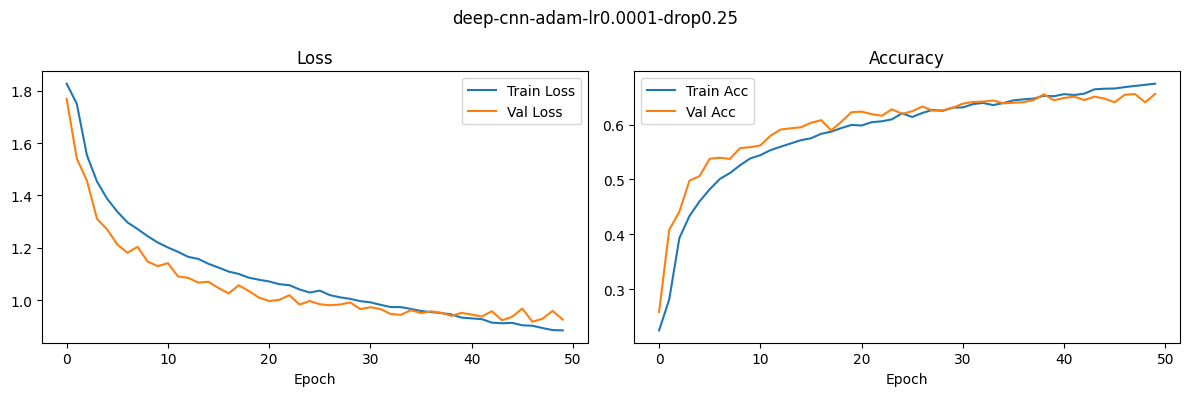

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▂▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train/loss,█▇▆▅▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇▇████████████████
val/loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.65569
best_val_loss,0.91823
epoch,50
final_train_accuracy,0.67445
learning_rate,0.0001



✅ Finished: deep-cnn-adam-lr0.0001-drop0.25



[deep-cnn-adam-lr0.001-drop0.5] Epoch 1/50 | Train Loss: 1.8430 Acc: 0.2373 | Val Loss: 1.7985 Acc: 0.2534 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.5] Epoch 2/50 | Train Loss: 1.8242 Acc: 0.2477 | Val Loss: 1.7889 Acc: 0.2562 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.5] Epoch 3/50 | Train Loss: 1.8153 Acc: 0.2494 | Val Loss: 1.7826 Acc: 0.2562 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.5] Epoch 4/50 | Train Loss: 1.8115 Acc: 0.2494 | Val Loss: 1.7880 Acc: 0.2562 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.5] Epoch 5/50 | Train Loss: 1.8045 Acc: 0.2494 | Val Loss: 1.7784 Acc: 0.2562 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.5] Epoch 6/50 | Train Loss: 1.8002 Acc: 0.2491 | Val Loss: 1.7731 Acc: 0.2562 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.5] Epoch 7/50 | Train Loss: 1.7939 Acc: 0.2508 | Val Loss: 1.7800 Acc: 0.2569 | LR: 0.001000
[deep-cnn-adam-lr0.001-drop0.5] Epoch 8/50 | Train Loss: 1.7853 Acc: 0.2582 | Val Loss: 1.7747 Acc: 0.2598 | LR: 0.001000
[deep-cnn-adam-lr0.001-d

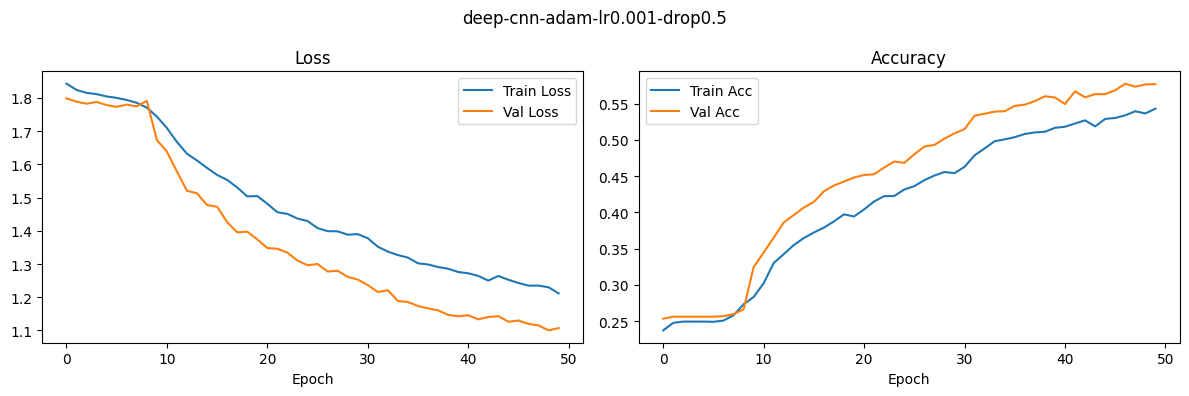

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▁▁▁▁▂▂▂▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███████
train/loss,█████▇▇▇▇▇▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▁▁▁▁▁▁▁▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██▇███████
val/loss,███████▇▆▆▅▅▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.5775
best_val_loss,1.10018
epoch,50
final_train_accuracy,0.543
learning_rate,0.001



✅ Finished: deep-cnn-adam-lr0.001-drop0.5



[deep-cnn-adam-batch32-drop0.25] Epoch 1/50 | Train Loss: 1.8330 Acc: 0.2390 | Val Loss: 1.8307 Acc: 0.2362 | LR: 0.001000
[deep-cnn-adam-batch32-drop0.25] Epoch 2/50 | Train Loss: 1.8112 Acc: 0.2469 | Val Loss: 1.8016 Acc: 0.2240 | LR: 0.001000
[deep-cnn-adam-batch32-drop0.25] Epoch 3/50 | Train Loss: 1.8014 Acc: 0.2502 | Val Loss: 1.7765 Acc: 0.2577 | LR: 0.001000
[deep-cnn-adam-batch32-drop0.25] Epoch 4/50 | Train Loss: 1.7648 Acc: 0.2735 | Val Loss: 1.6895 Acc: 0.3175 | LR: 0.001000
[deep-cnn-adam-batch32-drop0.25] Epoch 5/50 | Train Loss: 1.6853 Acc: 0.3135 | Val Loss: 1.5479 Acc: 0.3854 | LR: 0.001000
[deep-cnn-adam-batch32-drop0.25] Epoch 6/50 | Train Loss: 1.5925 Acc: 0.3607 | Val Loss: 1.5357 Acc: 0.3774 | LR: 0.001000
[deep-cnn-adam-batch32-drop0.25] Epoch 7/50 | Train Loss: 1.5248 Acc: 0.3897 | Val Loss: 1.4278 Acc: 0.4363 | LR: 0.001000
[deep-cnn-adam-batch32-drop0.25] Epoch 8/50 | Train Loss: 1.4786 Acc: 0.4086 | Val Loss: 1.3765 Acc: 0.4403 | LR: 0.001000
[deep-cnn-adam-b

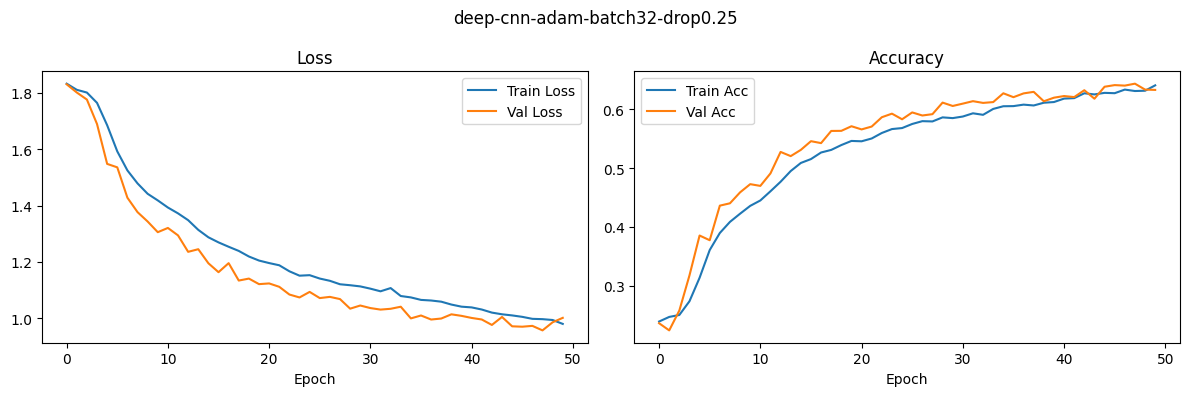

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▁▂▂▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
train/loss,███▇▇▅▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/accuracy,▁▁▂▃▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇▇████████████
val/loss,███▇▆▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.64385
best_val_loss,0.9564
epoch,50
final_train_accuracy,0.64101
learning_rate,0.001



✅ Finished: deep-cnn-adam-batch32-drop0.25



[deep-cnn-adam-noaug-drop0.25] Epoch 1/50 | Train Loss: 1.8301 Acc: 0.2383 | Val Loss: 1.8304 Acc: 0.2494 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] Epoch 2/50 | Train Loss: 1.8044 Acc: 0.2547 | Val Loss: 1.7800 Acc: 0.2558 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] Epoch 3/50 | Train Loss: 1.7478 Acc: 0.2880 | Val Loss: 1.6773 Acc: 0.3164 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] Epoch 4/50 | Train Loss: 1.6713 Acc: 0.3231 | Val Loss: 1.5528 Acc: 0.3999 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] Epoch 5/50 | Train Loss: 1.5516 Acc: 0.3875 | Val Loss: 1.4607 Acc: 0.4373 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] Epoch 6/50 | Train Loss: 1.4820 Acc: 0.4223 | Val Loss: 1.4502 Acc: 0.4514 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] Epoch 7/50 | Train Loss: 1.4331 Acc: 0.4373 | Val Loss: 1.3954 Acc: 0.4542 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] Epoch 8/50 | Train Loss: 1.3874 Acc: 0.4642 | Val Loss: 1.3850 Acc: 0.4859 | LR: 0.001000
[deep-cnn-adam-noaug-drop0.25] E

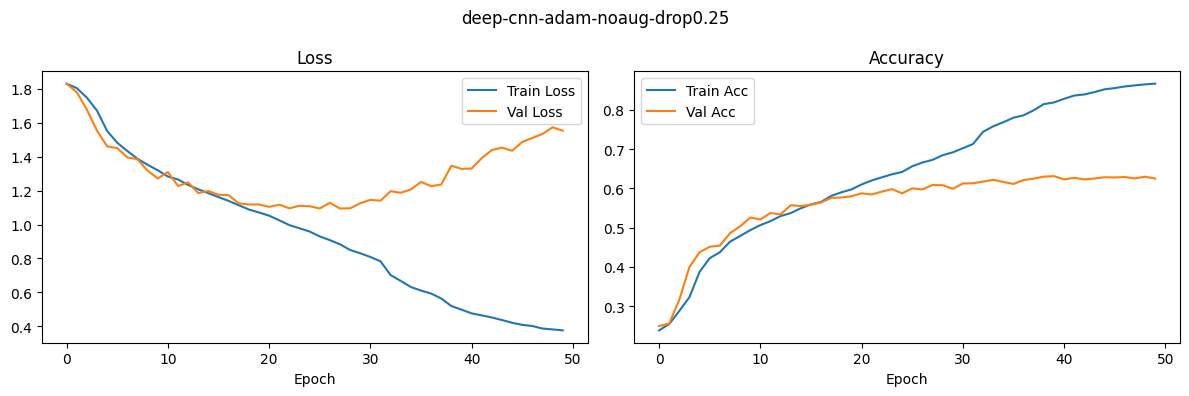

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,█████████████████████████▄▄▄▄▄▂▂▂▂▂▁▁▁▁▁
train/accuracy,▁▁▂▂▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███████
train/loss,███▇▇▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/accuracy,▁▁▂▄▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██▇███████████████
val/loss,██▇▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▅▅▅▅
best_val_accuracy,0.63131
best_val_loss,1.09448
epoch,50
final_train_accuracy,0.86677
learning_rate,6e-05



✅ Finished: deep-cnn-adam-noaug-drop0.25



In [14]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

experiments = [
    {
        "name": "deep-cnn-adam-lr0.001-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": True,
    },
    {
        "name": "deep-cnn-adam-lr0.0001-drop0.25",
        "learning_rate": 0.0001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": True,
    },
    {
        "name": "deep-cnn-adam-lr0.001-drop0.5",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.5,
        "augment": True,
    },
    {
        "name": "deep-cnn-adam-batch32-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 32,               # smaller batch → better generalization
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": True,
    },
    {
        "name": "deep-cnn-adam-noaug-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": False,               # no augmentation → shows its importance
    },
]

def get_optimizer(name, model, lr):
    if name == "Adam":
        return Adam(model.parameters(), lr=lr)
    elif name == "SGD":
        return SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "RMSprop":
        return RMSprop(model.parameters(), lr=lr)

def run_experiment(config):
    run = wandb.init(
        project="Facial_Expression_Recognition",
        name=config["name"],
        group="deep-cnn",
        tags=["deep-cnn", "batchnorm", "dropout", config["optimizer"].lower()],
        config={
            **config,
            "architecture": "DeepCNN",
            "num_conv_blocks": 4,
            "conv_filters": [64, 128, 256, 512],
            "fc_units": [1024, 512, 128],
            "batch_norm": True,
            "dataset": "FER2013"
        }
    )

    model = DeepCNN(dropout_rate=config["dropout_rate"]).to(device)
    optimizer = get_optimizer(config["optimizer"], model, config["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    # LR Scheduler — halves LR when val loss stops improving
    scheduler = ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=5
    )

    train_dataset_run = FERDatasetAugmented(X_train, y_train, augment=config["augment"])
    val_dataset_run   = FERDatasetAugmented(X_val, y_val, augment=False)

    train_loader = DataLoader(train_dataset_run, batch_size=config["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset_run, batch_size=config["batch_size"], shuffle=False)

    wandb.watch(model, log="all", log_freq=10)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(config["epochs"]):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # --- Validate ---
        model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = total_loss / len(val_loader)
        val_acc  = correct / total

        # Step scheduler based on val loss
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_loss,
            "train/accuracy": train_acc,
            "val/loss": val_loss,
            "val/accuracy": val_acc,
            "learning_rate": current_lr,   # track LR decay
        })

        print(f"[{config['name']}] Epoch {epoch+1}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.6f}")

    # --- Plot & Log ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(config["name"])

    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    wandb.log({"training_curves": wandb.Image(fig)})
    plt.show()
    plt.close(fig)

    wandb.summary["best_val_accuracy"]    = max(val_accs)
    wandb.summary["best_val_loss"]        = min(val_losses)
    wandb.summary["final_train_accuracy"] = train_accs[-1]
    wandb.summary["overfit_gap"]          = train_accs[-1] - val_accs[-1]

    wandb.finish()
    print(f"\n✅ Finished: {config['name']}\n{'='*60}\n")

for config in experiments:
    run_experiment(config)